### **Feature Engineering & Data Forensics — Hands-On Tutorial**

This notebook walks through every technique covered in the slide deck using public Kaggle datasets. **It does not download or load real data for you** — instead, every section tells you exactly which Kaggle dataset to use and where to put it. All code is structured so you can drop the CSVs in place and run cell-by-cell.

#### **Datasets used (download from Kaggle)**

| Lab | Dataset | Kaggle URL | Why we use it |
|---|---|---|---|
| 1, 2, 6 | **Titanic** | `kaggle competitions download -c titanic` | Mixed categorical + numeric, classic FE playground |
| 3, 4, 5, 7, 12 | **Santander Customer Transaction Prediction** | `kaggle competitions download -c santander-customer-transaction-prediction` | The exact dataset from the slides — has the synthetic-row problem |
| 6 | **American Express - Default Prediction** *(optional)* | `kaggle competitions download -c amex-default-prediction` | Heavy categorical → likelihood encoding |
| 8 | **Walmart Recruiting - Store Sales** | `kaggle competitions download -c walmart-recruiting-store-sales-forecasting` | Time series → lags, rolling windows |
| 9 | **Rossmann Store Sales**  | `kaggle competitions download -c rossmann-store-sales` | Entity embeddings on store IDs |

Drop the unzipped CSVs competition datasets into the folders

```
./data/titanic/
./data/santander/
./data/walmart/
./data/amex/
./data/rossman_store_sales/
```

#### **How to use this notebook**

- Each chapter is **self-contained**: you can run only the chapters whose datasets you have.
- Every chapter starts with a short recap of the relevant slide and ends with the takeaway you should remember.
- Cells marked `# DEMO` use tiny synthetic toy data so the technique runs even without the Kaggle file.


In [1]:
# Standard scientific stack
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 140)
np.random.seed(42)

DATA_DIR = './data'  

def path(*parts):
    return os.path.join(DATA_DIR, *parts)

def section(title):
    print('\n' + '=' * 70)
    print(title)
    print('=' * 70)

print('Setup complete. DATA_DIR =', os.path.abspath(DATA_DIR))


Setup complete. DATA_DIR = /home/jaumemanero/_DEVELOPMENT/_Notebooks/Machine-Learning-II/11-Feature-engineering/data


In [2]:
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, KBinsDiscretizer
from sklearn.metrics import roc_auc_score
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold, mutual_info_classif

print('Core sklearn imports OK')


Core sklearn imports OK


#### **LAB 1 — Univariate Transforms**

> *Slide reference: "The Feature Engineering Toolbox" — univariate fixes distributions but does not add information.*

These are applied **one column at a time**. They reshape the distribution but cannot reveal new structure. Useful as a baseline / preprocessing step.

We will demonstrate:
1. Log / `log1p` transform (skewed positive features)
2. Outlier clipping (winsorisation)
3. Min-Max and Z-score scaling
4. Rank transform (most robust to outliers)

**Dataset:** Titanic — we use the `Fare` column which is heavily right-skewed.


In [3]:
#make sure your titanic data is in ./data/titanic
titanic = pd.read_csv(path('titanic', 'train.csv'))
fare = titanic['Fare'].dropna().values
print('Loaded Titanic. Fare stats:')
print(pd.Series(fare).describe())

Loaded Titanic. Fare stats:
count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
dtype: float64


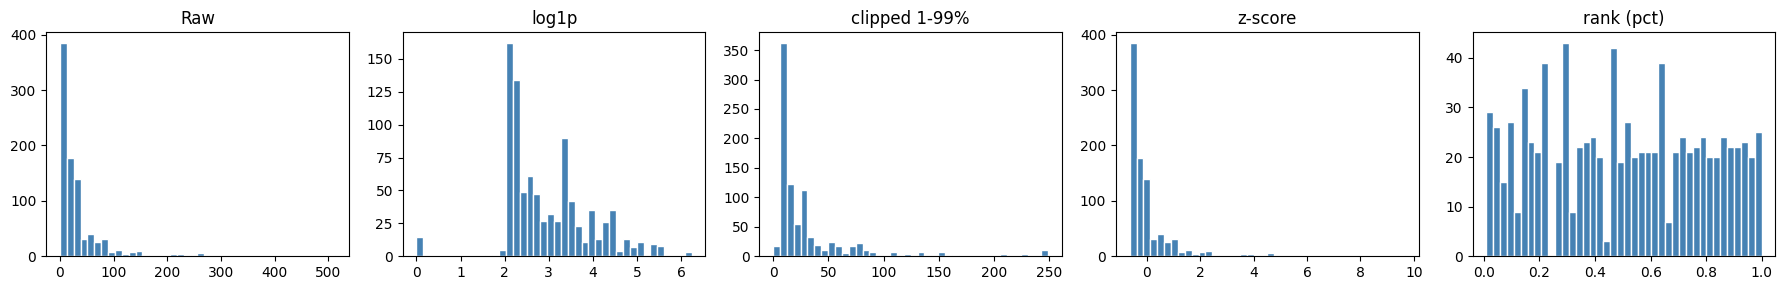

In [4]:
# 1. Log transform
fare_log = np.log1p(fare)  # log1p handles 0 safely

# 2. Outlier clipping at the 1st / 99th percentile (winsorisation)
lo, hi = np.percentile(fare, [1, 99])
fare_clipped = np.clip(fare, lo, hi)

# 3. Z-score scaling
fare_z = (fare - fare.mean()) / fare.std()

# 4. Rank transform — values become uniform on [0, 1]
fare_rank = pd.Series(fare).rank(pct=True).values

# Compare distributions visually
fig, axes = plt.subplots(1, 5, figsize=(18, 3))
for ax, data, name in zip(
    axes,
    [fare, fare_log, fare_clipped, fare_z, fare_rank],
    ['Raw', 'log1p', 'clipped 1-99%', 'z-score', 'rank (pct)']):
    ax.hist(data, bins=40, color='steelblue', edgecolor='white')
    ax.set_title(name)
plt.tight_layout()
plt.show()


**Takeaway.** None of these transforms add new information — they only make the distribution easier for the model to digest (especially linear models and neural nets). Tree-based models are largely invariant to monotonic transforms, which is why structural features will give us much more lift in later chapters.


#### **LAB 2 — Multivariate Transforms**

> *Slide reference: "Multivariate — combines two or more columns; captures relationships."*

We build:
1. Polynomial / interaction terms `x_i * x_j`
2. Ratios `x_i / x_j`
3. Differences `x_i - x_j`
4. PCA components as features (covered properly in Chapter 11)

**Dataset:** Titanic — `SibSp`, `Parch`, `Age`, `Fare`.


In [5]:
df = pd.read_csv(path('titanic', 'train.csv'))

# 1. Family size = SibSp + Parch + 1 (the passenger themselves)
df['family_size'] = df['SibSp'] + df['Parch'] + 1

# 2. Is alone (family_size == 1)
df['is_alone'] = (df['family_size'] == 1).astype(int)

# 3. Fare per family member
df['fare_per_person'] = df['Fare'] / df['family_size']

# 4. Age * class interaction (younger first-class passengers had different survival)
if 'Pclass' in df.columns:
    df['age_x_class'] = df['Age'] * df['Pclass']

# 5. Polynomial: Age squared (captures non-linear age effect)
df['age_sq'] = df['Age'] ** 2

display_cols = ['SibSp', 'Parch', 'Age', 'Fare', 'family_size',
                'is_alone', 'fare_per_person', 'age_sq']
df[display_cols].head()


,SibSp,Parch,Age,Fare,family_size,is_alone,fare_per_person,age_sq
0,1,0,22.0,7.2500,2,0,3.62500,484.0
1,1,0,38.0,71.2833,2,0,35.64165,1444.0
2,0,0,26.0,7.9250,1,1,7.92500,676.0
3,1,0,35.0,53.1000,2,0,26.55000,1225.0
4,0,0,35.0,8.0500,1,1,8.05000,1225.0


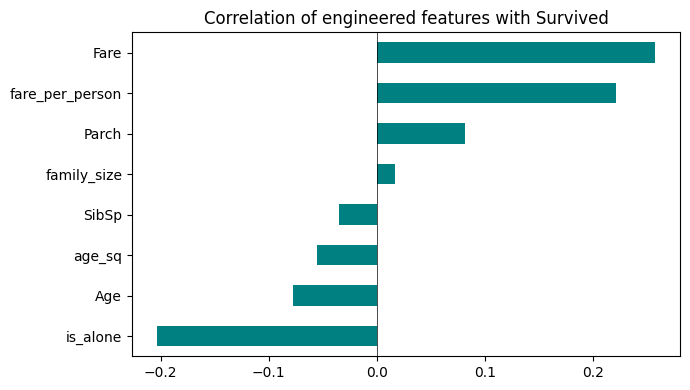

In [6]:
# Quick sanity check: do these features correlate with the target?
if 'Survived' in df.columns:
    corrs = df[display_cols + ['Survived']].corr()['Survived'].drop('Survived')
    corrs.sort_values().plot.barh(figsize=(7, 4), color='teal')
    plt.title('Correlation of engineered features with Survived')
    plt.axvline(0, color='black', lw=0.5)
    plt.tight_layout()
    plt.show()


**Takeaway.** Multivariate features encode domain knowledge (a family of 5 behaves differently from a single passenger). They're computationally cheap but require you to *know something* about the data. The next chapters cover **structural** features — which work even on fully anonymised data.


#### **LAB 3 — Data Forensics: Detecting Synthetic Rows**

> *Slide reference: "The Santander Competition Mystery Test Set" — only 100K of 200K test rows were real.*

This is the chapter where the slides really come alive. We rebuild the **synthetic-row detector** from the deck.

#### Core insight
> If a value appears **exactly once** across all 200,000 rows, it is the fingerprint of a real observation. Synthetic rows borrow values from real rows — they cannot own a unique value.

A row is **real** if it contains at least one globally-unique value across any of its features.


In [7]:
# Load the Santander test set (200,000 rows, 200 numeric features)
santander_test = pd.read_csv(path('santander', 'test.csv'))
feat_cols = [c for c in santander_test.columns if c.startswith('var_')]
print(f'Loaded {len(santander_test):,} rows, {len(feat_cols)} features.')

Loaded 200,000 rows, 200 features.


In [8]:
# The detector — exactly the algorithm from slide 15
def find_real_rows(df, feat_cols):
    """Return a boolean mask: True = the row contains at least one globally
    unique value in any feature column => real row."""
    real_mask = np.zeros(len(df), dtype=bool)
    for col in feat_cols:
        vals = df[col].values
        unique_vals, counts = np.unique(vals, return_counts=True)
        unique_set = set(unique_vals[counts == 1])           # values that appear exactly once
        real_mask |= np.array([v in unique_set for v in vals])
    return real_mask

real_mask = find_real_rows(santander_test, feat_cols)
print(f'Real rows:      {real_mask.sum():,}')
print(f'Synthetic rows: {(~real_mask).sum():,}')
print(f'Ratio real:     {real_mask.mean():.1%}')


Real rows:      100,000
Synthetic rows: 100,000
Ratio real:     50.0%


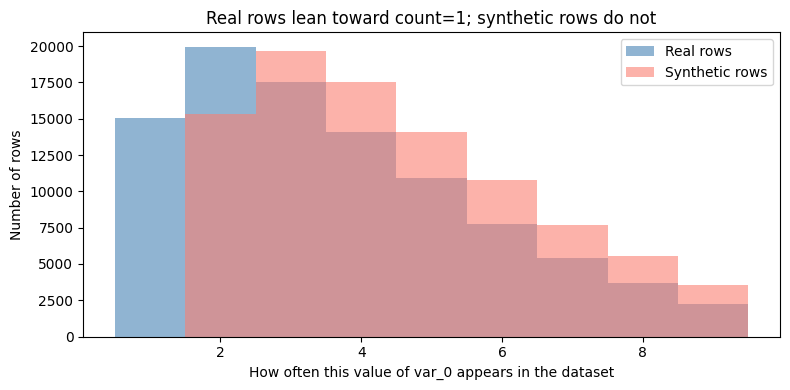

In [9]:
# Visualise: histogram of value-count distributions, real vs synthetic
# We expect real rows to contain MORE count==1 values than synthetic ones.
sample_col = feat_cols[0]
vc = santander_test[sample_col].value_counts()
counts_real = vc[santander_test.loc[real_mask, sample_col]].values
counts_fake = vc[santander_test.loc[~real_mask, sample_col]].values

fig, ax = plt.subplots(figsize=(8, 4))
bins = np.arange(1, 11) - 0.5
ax.hist(counts_real, bins=bins, alpha=0.6, label='Real rows', color='steelblue')
ax.hist(counts_fake, bins=bins, alpha=0.6, label='Synthetic rows', color='salmon')
ax.set_xlabel(f'How often this value of {sample_col} appears in the dataset')
ax.set_ylabel('Number of rows')
ax.set_title('Real rows lean toward count=1; synthetic rows do not')
ax.legend()
plt.tight_layout()
plt.show()


**Takeaway.** With this single check we have separated 'real' test rows from synthetic noise. Every frequency-based feature we build from now on will use **only the real test rows + the training set**. This is the *clean pool* the slides keep referring to.


#### **LAB 4 — Value Count (VC) Features**

> *Slide reference: "The Power of Value Counts" — instead of using the raw value `x`, create a new feature: how many times does `x` appear?*

Trees split on magnitude (`x > 7`). VC features let trees split on **rarity** (`count(x) == 1`), which is often the true predictive signal.

#### The Critical Pitfall

If you compute frequencies on `train ∪ test_full` (including synthetic rows), the counts are **inflated** and the rarity signal is destroyed. The slides call this *leaking synthetic noise*.

**Correct rule:** compute VC on `train ∪ real_test_rows` only, then map back to *all* rows.


In [10]:
santander_train = pd.read_csv(path('santander', 'train.csv'))
print(f'Train: {len(santander_train):,} rows')

# Make sure we use the same feature columns
feat_cols = [c for c in feat_cols if c in santander_train.columns and c in santander_test.columns]

# THE CLEAN POOL
clean_pool = pd.concat([
    santander_train[feat_cols],
    santander_test.loc[real_mask, feat_cols],
], axis=0, ignore_index=True)

print(f'Clean pool size: {len(clean_pool):,}')
print(f'(train {len(santander_train):,} + real test {real_mask.sum():,})')


Train: 200,000 rows
Clean pool size: 300,000
(train 200,000 + real test 100,000)


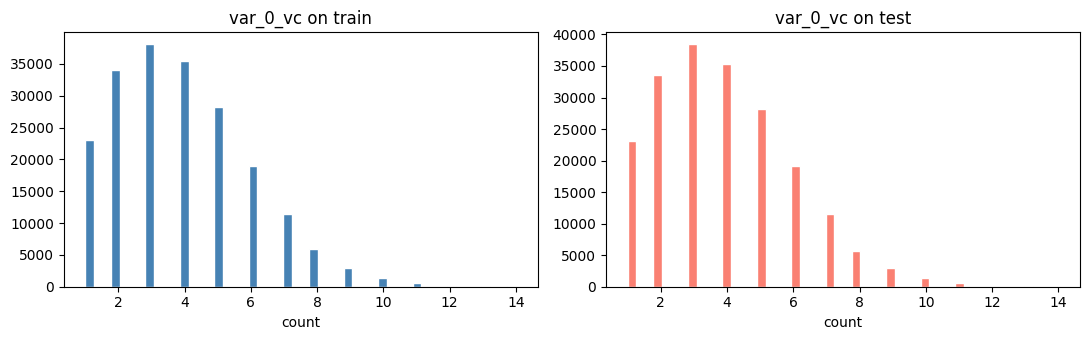

In [11]:
# For each feature, build a value -> count dictionary using the clean pool
def build_vc_maps(pool, cols):
    return {col: pool[col].value_counts().to_dict() for col in cols}

vc_maps = build_vc_maps(clean_pool, feat_cols)

# Apply VC to BOTH train and test (test gets the same map; synthetic rows just get
# whatever count their borrowed values happened to have in the clean pool).
def add_vc_features(df, vc_maps, cols, suffix='_vc'):
    out = df.copy()
    for col in cols:
        out[col + suffix] = df[col].map(vc_maps[col]).fillna(0).astype(int)
    return out

train_vc = add_vc_features(santander_train, vc_maps, feat_cols)
test_vc  = add_vc_features(santander_test,  vc_maps, feat_cols)

# Inspect: distribution of VC for one variable
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].hist(train_vc[feat_cols[0] + '_vc'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title(f'{feat_cols[0]}_vc on train')
axes[0].set_xlabel('count')
axes[1].hist(test_vc[feat_cols[0] + '_vc'], bins=50, color='salmon', edgecolor='white')
axes[1].set_title(f'{feat_cols[0]}_vc on test')
axes[1].set_xlabel('count')
plt.tight_layout(); plt.show()


In [12]:
# Demonstrate the LEAKAGE that happens if you naively use the full test set
naive_pool = pd.concat([santander_train[feat_cols], santander_test[feat_cols]], axis=0)
naive_maps = build_vc_maps(naive_pool, feat_cols[:1])  # one column is enough to show the effect

col = feat_cols[0]
clean_counts_unique = sum(1 for c in vc_maps[col].values() if c == 1)
naive_counts_unique = sum(1 for c in naive_maps[col].values() if c == 1)
print(f'Number of values that appear exactly ONCE in {col}:')
print(f'  Clean pool (train + real test):      {clean_counts_unique:,}')
print(f'  Naive pool (train + full test):      {naive_counts_unique:,}')
print(f'\nThe naive pool inflates counts and destroys the rarity signal.')


Number of values that appear exactly ONCE in var_0:
  Clean pool (train + real test):      34,577
  Naive pool (train + full test):      27,301

The naive pool inflates counts and destroys the rarity signal.


**Takeaway.** VC features are dataset-level statistics. They turn anonymous numeric features (`var_0`, `var_1`, …) into rich rarity scores that trees love. **Always compute them on the clean pool**, never on the full test set.


#### **LAB 5 — Magic Features (X × X_count)**

> *Slide reference: "Magic features encode magnitude × rarity in a single feature."*

$$X_\text{magic} = X \times X_\text{count}$$

If a value is unique (`count = 1`), magic equals the raw value. If it's common (`count = 8341`), magic amplifies it. Trees can now split on the *interaction* between value and prevalence in a single step.


In [13]:
# Add magic features for the first 10 numeric variables (use all 200 in a real run)
magic_cols_src = feat_cols[:10]
for col in magic_cols_src:
    train_vc[col + '_magic'] = train_vc[col] * train_vc[col + '_vc']
    test_vc[col  + '_magic'] = test_vc[col]  * test_vc[col  + '_vc']

# Show how the magic feature spreads values out
col = magic_cols_src[0]
sample = train_vc[[col, col + '_vc', col + '_magic']].sample(8, random_state=1)
sample


,var_0,var_0_vc,var_0_magic
49673,11.5208,5,57.6040
171551,10.6327,2,21.2654
5506,13.4346,5,67.1730
38370,4.8650,4,19.4600
36930,9.8466,3,29.5398
167783,6.6022,2,13.2044
67487,11.4589,5,57.2945
101486,18.2815,3,54.8445


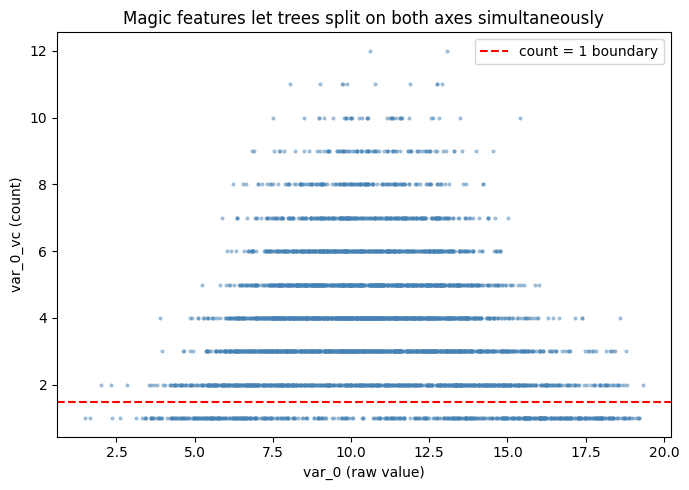

In [14]:
# Visual: the count==1 boundary that the slide describes
fig, ax = plt.subplots(figsize=(7, 5))
sub = train_vc.sample(min(5000, len(train_vc)), random_state=1)
ax.scatter(sub[col], sub[col + '_vc'], s=4, alpha=0.4, c='steelblue')
ax.axhline(1.5, color='red', ls='--', label='count = 1 boundary')
ax.set_xlabel(col + ' (raw value)')
ax.set_ylabel(col + '_vc (count)')
ax.set_title('Magic features let trees split on both axes simultaneously')
ax.legend(); plt.tight_layout(); plt.show()


**Takeaway.** A magic feature packs two signals (value + rarity) into one column. Gradient-boosted trees pick up the interaction automatically. The slides report a typical lift of **+0.005–0.01 AUC** on Santander from adding magic features on top of plain VC.


#### **LAB 6 — Likelihood / Target Encoding (with smoothing & K-Fold)**

> *Slide reference: "Target Encoding — The Problem & The Fix" + "Method Comparison".*

The naive encoding `TE(c) = mean(y | x = c)` is unstable for rare categories: a category seen once gets `0` or `1` exactly, which leaks the target.

#### Two safe variants we implement here
1. **Smoothed (James–Stein style)**:
$$\text{TE}(c) = \lambda_c \bar y_c + (1 - \lambda_c) \bar y_\text{global}, \quad \lambda_c = \frac{n_c}{n_c + k}$$
2. **K-Fold target encoding** (out-of-fold) — the standard for GBMs and NNs.


In [15]:
# Use Titanic with high-cardinality engineered category
df = pd.read_csv(path('titanic', 'train.csv'))

cat_col = 'Ticket'      # high cardinality on Titanic
y_col   = 'Survived'

# 1. Smoothed target encoding — single pass, fit on whole training data
def smoothed_target_encoding(df, cat_col, y_col, k=10):
    global_mean = df[y_col].mean()
    agg = df.groupby(cat_col)[y_col].agg(['mean', 'count']).reset_index()
    agg['lambda']    = agg['count'] / (agg['count'] + k)
    agg['te_smooth'] = agg['lambda'] * agg['mean'] + (1 - agg['lambda']) * global_mean
    return dict(zip(agg[cat_col], agg['te_smooth']))

te_map = smoothed_target_encoding(df, cat_col, y_col, k=10)
df[cat_col + '_te_smooth'] = df[cat_col].map(te_map)
df[[cat_col, y_col, cat_col + '_te_smooth']].head(8)


,Ticket,Survived,Ticket_te_smooth
0,A/5 21171,0,0.348944
1,PC 17599,1,0.439853
2,STON/O2. 3101282,1,0.439853
3,113803,1,0.403199
4,373450,0,0.348944
5,330877,0,0.348944
6,17463,0,0.348944
7,349909,0,0.274170


In [16]:
# 2. K-Fold target encoding — every row encoded by a model that did NOT see it
def kfold_target_encoding(df, cat_col, y_col, n_splits=5, k=10, seed=42):
    """Out-of-fold smoothed target encoding. Returns a Series aligned to df."""
    out = np.full(len(df), np.nan)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    global_mean = df[y_col].mean()
    for fold, (tr_idx, val_idx) in enumerate(skf.split(df, df[y_col])):
        fold_train = df.iloc[tr_idx]
        agg = fold_train.groupby(cat_col)[y_col].agg(['mean', 'count'])
        agg['lambda']  = agg['count'] / (agg['count'] + k)
        agg['te']      = agg['lambda'] * agg['mean'] + (1 - agg['lambda']) * global_mean
        mapper = agg['te'].to_dict()
        out[val_idx] = df.iloc[val_idx][cat_col].map(mapper).fillna(global_mean).values
    return pd.Series(out, index=df.index)

df[cat_col + '_te_kfold'] = kfold_target_encoding(df, cat_col, y_col, n_splits=5, k=10)
df[[cat_col, y_col, cat_col + '_te_smooth', cat_col + '_te_kfold']].head(8)


,Ticket,Survived,Ticket_te_smooth,Ticket_te_kfold
0,A/5 21171,0,0.348944,0.383838
1,PC 17599,1,0.439853,0.383838
2,STON/O2. 3101282,1,0.439853,0.383838
3,113803,1,0.403199,0.348944
4,373450,0,0.348944,0.383838
5,330877,0,0.348944,0.383838
6,17463,0,0.348944,0.383838
7,349909,0,0.274170,0.319865


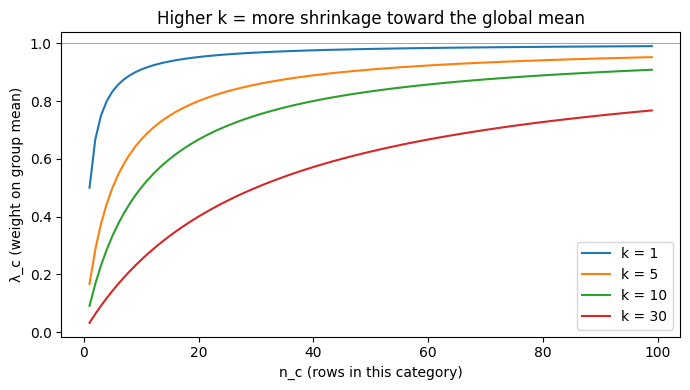

In [17]:
# How much does smoothing matter? Plot lambda vs n_c for several k values
n_c = np.arange(1, 100)
fig, ax = plt.subplots(figsize=(7, 4))
for k in [1, 5, 10, 30]:
    ax.plot(n_c, n_c / (n_c + k), label=f'k = {k}')
ax.axhline(1, color='gray', lw=0.5)
ax.set_xlabel('n_c (rows in this category)')
ax.set_ylabel('λ_c (weight on group mean)')
ax.set_title('Higher k = more shrinkage toward the global mean')
ax.legend(); plt.tight_layout(); plt.show()


**Takeaway.** Smoothed encoding handles rare categories gracefully; K-Fold encoding additionally prevents target leakage. **For test data: always apply the encoding fit on training only.** CatBoost's *Ordered TE* and *Leave-One-Out* (slide 36) follow the same principle with even tighter safety guarantees.


#### **LAB 7 — Binning & Discretisation**

> *Slide reference: "When floats are actually categories — discretising reduces noise and creates tree-friendly splits."*

Equal-width bins are intuitive but brittle to outliers. Equal-frequency (quantile) bins are the workhorse.


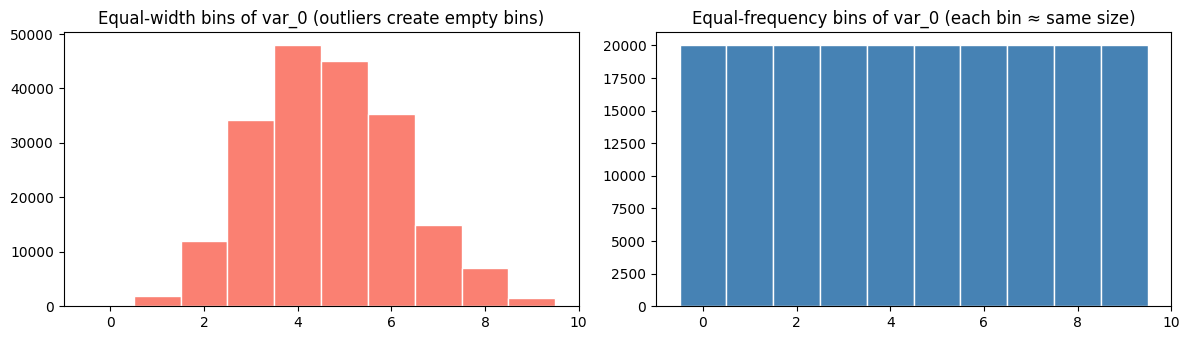

In [18]:
# Use one Santander column if available, else fall back to the Titanic Fare
x = santander_train[feat_cols[0]].values
name = feat_cols[0]

# Equal-width and equal-frequency binning via sklearn
disc_w = KBinsDiscretizer(n_bins=10, encode='ordinal', strategy='uniform')
disc_q = KBinsDiscretizer(n_bins=10, encode='ordinal', strategy='quantile')
bin_w = disc_w.fit_transform(x.reshape(-1, 1)).ravel()
bin_q = disc_q.fit_transform(x.reshape(-1, 1)).ravel()

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
axes[0].hist(bin_w, bins=np.arange(11) - 0.5, color='salmon', edgecolor='white')
axes[0].set_title(f'Equal-width bins of {name} (outliers create empty bins)')
axes[1].hist(bin_q, bins=np.arange(11) - 0.5, color='steelblue', edgecolor='white')
axes[1].set_title(f'Equal-frequency bins of {name} (each bin ≈ same size)')
plt.tight_layout(); plt.show()


**Takeaway.** For skewed features, prefer **quantile** bins. For neural networks, treat the bin index as a categorical column and feed it through an embedding layer instead of one-hot encoding (covered in LAB 9).


#### **Chapter 8 — Temporal Features: Lags, Rolling Windows, Cyclical Encoding**

> *Slide reference: "Lag Features — The Past as a Predictor", "Rolling Window Statistics", "Calendar Decomposition & Cyclical Encoding".*

**Dataset:** Walmart Recruiting — Store Sales Forecasting. Each row is `(Store, Dept, Date, Weekly_Sales)`.

### Look-ahead leakage warning
Always call `.shift(1)` *before* any rolling aggregation. Otherwise the value at time `t` ends up inside the window used to predict `t`.


In [19]:
walmart = pd.read_csv(path('walmart_recruiting', 'train.csv'), parse_dates=['Date'])
walmart = walmart.sort_values(['Store', 'Dept', 'Date'])
print(f'Loaded Walmart: {len(walmart):,} rows')

Loaded Walmart: 421,570 rows


In [20]:
# Lag features — group by (Store, Dept) so we don't bleed across series
g = walmart.groupby(['Store', 'Dept'])['Weekly_Sales']
walmart['lag_1']  = g.shift(1)
walmart['lag_4']  = g.shift(4)    # ~1 month
walmart['lag_52'] = g.shift(52)   # same week last year

# Rolling statistics — shift(1) FIRST so we never include the current value
walmart['roll4_mean']  = g.transform(lambda s: s.shift(1).rolling(4).mean())
walmart['roll4_std']   = g.transform(lambda s: s.shift(1).rolling(4).std())
walmart['roll12_mean'] = g.transform(lambda s: s.shift(1).rolling(12).mean())

walmart[['Store', 'Date', 'Weekly_Sales', 'lag_1', 'lag_4', 'lag_52',
         'roll4_mean', 'roll4_std', 'roll12_mean']].head(10)


,Store,Date,Weekly_Sales,lag_1,lag_4,lag_52,roll4_mean,roll4_std,roll12_mean
0,1,2010-02-05,24924.50,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2010-02-12,46039.49,24924.50,NaN,NaN,NaN,NaN,NaN
2,1,2010-02-19,41595.55,46039.49,NaN,NaN,NaN,NaN,NaN
3,1,2010-02-26,19403.54,41595.55,NaN,NaN,NaN,NaN,NaN
4,1,2010-03-05,21827.90,19403.54,24924.50,NaN,32990.7700,12832.106391,NaN
5,1,2010-03-12,21043.39,21827.90,46039.49,NaN,32216.6200,13554.047185,NaN
6,1,2010-03-19,22136.64,21043.39,41595.55,NaN,25967.5950,10467.484020,NaN
7,1,2010-03-26,26229.21,22136.64,19403.54,NaN,21102.8675,1222.784968,NaN
8,1,2010-04-02,57258.43,26229.21,21827.90,NaN,22809.2850,2325.929203,NaN
9,1,2010-04-09,42960.91,57258.43,21043.39,NaN,31666.9175,17206.391261,NaN


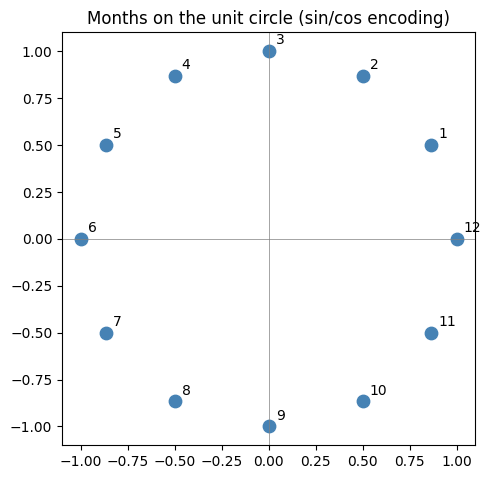

In [21]:
# Calendar decomposition + cyclical sin/cos encoding
walmart['year']    = walmart['Date'].dt.year
walmart['month']   = walmart['Date'].dt.month
walmart['week']    = walmart['Date'].dt.isocalendar().week.astype(int)
walmart['dow']     = walmart['Date'].dt.dayofweek
walmart['is_wknd'] = (walmart['dow'] >= 5).astype(int)

# Cyclical encoding: maps period boundaries onto a unit circle so e.g. December and
# January are NEAR each other — a tree no longer needs deep splits to figure that out.
for col, period in [('month', 12), ('dow', 7), ('week', 52)]:
    walmart[f'{col}_sin'] = np.sin(2 * np.pi * walmart[col] / period)
    walmart[f'{col}_cos'] = np.cos(2 * np.pi * walmart[col] / period)

# Visualise: month encoding on the unit circle
months = pd.DataFrame({'m': range(1, 13)})
months['sin'] = np.sin(2 * np.pi * months['m'] / 12)
months['cos'] = np.cos(2 * np.pi * months['m'] / 12)

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(months['cos'], months['sin'], s=80, c='steelblue')
for _, r in months.iterrows():
    ax.annotate(int(r['m']), (r['cos'], r['sin']),
                xytext=(5, 5), textcoords='offset points')
ax.set_aspect('equal'); ax.set_title('Months on the unit circle (sin/cos encoding)')
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
plt.tight_layout(); plt.show()


**Takeaway.** For any time-ordered dataset, lags and rolling stats are the strongest single predictors. Calendar decomposition + cyclical encoding free the model from having to learn that month 12 and month 1 are adjacent.


#### **LAB 9 — Entity Embeddings for High-Cardinality Categoricals (Rossmann)**

> *Slide reference: "Entity Embeddings — Motivation / Results / Implementation"; Guo & Berkhahn (2016) on Rossmann store IDs.*

**Dataset:** Rossmann Store Sales — 1,115 stores across Germany, ~1M daily rows.

Files we expect under `./data/rossmann/`:
- `train.csv` — `Store, DayOfWeek, Date, Sales, Customers, Open, Promo, StateHoliday, SchoolHoliday`
- `store.csv` — `Store, StoreType, Assortment, CompetitionDistance, …`

#### Using Embeddings

1. A neural net with an `Embedding` layer over `Store` (1,115 categories → `d`-dim vectors).
2. Side inputs: a few raw numeric / categorical columns (`DayOfWeek`, `Promo`, `SchoolHoliday`, …).
3. After training, we **extract the learned embedding matrix** and inspect it: do stores with the same `StoreType` and `Assortment` cluster together, *without ever showing those columns to the embedding layer?*
4. Finally we demonstrate the **two-stage pipeline** from the slide: freeze embeddings, feed them as 8 extra numeric columns into LightGBM.

> Requires TensorFlow/Keras — `pip install tensorflow`. If you'd rather skip the NN training, just run the data-loading cell and the LightGBM cell at the end uses the saved embedding matrix.

In [37]:
# 9.1 — Load Rossmann
import os

ross_train = pd.read_csv(path('rossmann_store_sales', 'train.csv'),
                         parse_dates=['Date'], low_memory=False)
ross_store = pd.read_csv(path('rossmann_store_sales', 'store.csv'))

# Drop closed days (Sales == 0 when Open == 0) — they add noise to embedding training
ross_train = ross_train[ross_train['Open'] == 1].copy()
ross_train = ross_train[ross_train['Sales'] > 0].copy()

print(f'Train rows (open days only): {len(ross_train):,}')
print(f'Stores: {ross_train["Store"].nunique():,}')
print(f'Date range: {ross_train.Date.min().date()} → {ross_train.Date.max().date()}')
ross_train.head(3)


Train rows (open days only): 844,338
Stores: 1,115
Date range: 2013-01-01 → 2015-07-31


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1


In [38]:
# 9.2 — Minimal feature prep for the embedding model
# We deliberately keep the side inputs SMALL so the Store embedding has to do real work.

# StateHoliday is mixed type ('0', 'a', 'b', 'c') — collapse to flag
ross_train['StateHoliday'] = (ross_train['StateHoliday'].astype(str) != '0').astype(int)

# Calendar decomposition (same trick as Chapter 8)
ross_train['Year']  = ross_train['Date'].dt.year
ross_train['Month'] = ross_train['Date'].dt.month
ross_train['Day']   = ross_train['Date'].dt.day

# Map Store IDs to a contiguous integer range [0, N_STORES) — required by Embedding layers
store_ids   = sorted(ross_train['Store'].unique())
store_to_ix = {s: i for i, s in enumerate(store_ids)}
ross_train['store_idx'] = ross_train['Store'].map(store_to_ix)
N_STORES = len(store_ids)

# Target: log1p(Sales) is the standard for this competition (RMSPE metric)
ross_train['log_sales'] = np.log1p(ross_train['Sales'])

NUMERIC_COLS = ['DayOfWeek', 'Promo', 'SchoolHoliday', 'StateHoliday',
                'Year', 'Month', 'Day']

# Scale numeric inputs so the network trains cleanly
num_scaler = StandardScaler().fit(ross_train[NUMERIC_COLS])
X_num = num_scaler.transform(ross_train[NUMERIC_COLS]).astype('float32')
X_store = ross_train['store_idx'].values.astype('int32')
y = ross_train['log_sales'].values.astype('float32')

print(f'N_STORES = {N_STORES}, X_num.shape = {X_num.shape}, X_store.shape = {X_store.shape}')

N_STORES = 1115, X_num.shape = (844338, 7), X_store.shape = (844338,)


In [39]:
# 9.3 — Build and train the embedding model
import tensorflow as tf
from tensorflow.keras import layers, Model
tf.random.set_seed(42)

# Rule of thumb from the slide: d = min(50, ceil(K/2))
EMB_DIM = min(50, (N_STORES + 1) // 2)
# For 1115 stores that gives 50, but smaller embeddings train faster and visualise better
EMB_DIM = 8
print(f'Embedding dim: {EMB_DIM}')

store_in = layers.Input(shape=(1,), dtype='int32', name='store_id')
num_in   = layers.Input(shape=(len(NUMERIC_COLS),), name='num_features')

emb      = layers.Embedding(N_STORES, EMB_DIM, name='store_embedding')(store_in)
emb_flat = layers.Flatten()(emb)
x        = layers.Concatenate()([emb_flat, num_in])
x        = layers.Dense(64, activation='relu')(x)
x        = layers.Dropout(0.2)(x)
x        = layers.Dense(32, activation='relu')(x)
out      = layers.Dense(1)(x)

model = Model([store_in, num_in], out)
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

Embedding dim: 8


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ store_id            │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ store_embedding     │ (None, 1, 8)      │      8,920 │ store_id[0][0]    │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 8)         │          0 │ store_embedding[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ num_features        │ (None, 7)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 15)        │          0 │ flatten_1[0][0],  │
│ (Concatenate)       │                   │            │ num_features[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │      1,024 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 32)        │      2,080 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1)         │         33 │ dense_4[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 12,057 (47.10 KB)

 Trainable params: 12,057 (47.10 KB)

 Non-trainable params: 0 (0.00 B)

In [40]:
# Train. ~2-3 epochs is enough to get useful embeddings — we are not chasing leaderboard score.
history = model.fit(
    [X_store, X_num], y,
    epochs=50,
    batch_size=4096,
    validation_split=0.1,
    verbose=2,
)


Epoch 1/50
186/186 - 1s - 6ms/step - loss: 18.3573 - mae: 3.0977 - val_loss: 0.8596 - val_mae: 0.7127
Epoch 2/50
186/186 - 1s - 3ms/step - loss: 1.0654 - mae: 0.8233 - val_loss: 0.6221 - val_mae: 0.6311
Epoch 3/50
186/186 - 1s - 3ms/step - loss: 0.8001 - mae: 0.7126 - val_loss: 0.4498 - val_mae: 0.5469
Epoch 4/50
186/186 - 1s - 4ms/step - loss: 0.6552 - mae: 0.6444 - val_loss: 0.3042 - val_mae: 0.4443
Epoch 5/50
186/186 - 1s - 4ms/step - loss: 0.5661 - mae: 0.5984 - val_loss: 0.2097 - val_mae: 0.3603
Epoch 6/50
186/186 - 1s - 3ms/step - loss: 0.5110 - mae: 0.5688 - val_loss: 0.1432 - val_mae: 0.2890
Epoch 7/50
186/186 - 1s - 3ms/step - loss: 0.4698 - mae: 0.5447 - val_loss: 0.1067 - val_mae: 0.2440
Epoch 8/50
186/186 - 1s - 3ms/step - loss: 0.4373 - mae: 0.5258 - val_loss: 0.0834 - val_mae: 0.2112
Epoch 9/50
186/186 - 1s - 3ms/step - loss: 0.4109 - mae: 0.5092 - val_loss: 0.0752 - val_mae: 0.1999
Epoch 10/50
186/186 - 1s - 4ms/step - loss: 0.3871 - mae: 0.4942 - val_loss: 0.0644 - val_

In [41]:
# 9.4 — Extract the learned embedding matrix
emb_matrix = model.get_layer('store_embedding').get_weights()[0]
print(f'Embedding matrix shape: {emb_matrix.shape}')   # (N_STORES, EMB_DIM)

# Wrap in a DataFrame indexed by the original Kaggle Store ID
emb_df = pd.DataFrame(
    emb_matrix,
    index=pd.Index(store_ids, name='Store'),
    columns=[f'emb_{i}' for i in range(EMB_DIM)],
)
emb_df.head()

Embedding matrix shape: (1115, 8)


,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,emb_7
Store,,,,,,,,
1,-0.143272,0.144885,-0.164836,0.073179,-0.175189,-0.115993,-0.150672,-0.172837
2,-0.210507,0.137292,-0.102570,0.245378,-0.106564,-0.182936,-0.165132,-0.132559
3,-0.211103,0.197455,-0.161861,0.249594,-0.142914,-0.253454,-0.181895,-0.227982
4,-0.200817,0.258446,-0.293276,0.075005,-0.292945,-0.258256,-0.182512,-0.249162
5,-0.194818,0.146185,-0.103808,0.215983,-0.114479,-0.177734,-0.168889,-0.067194


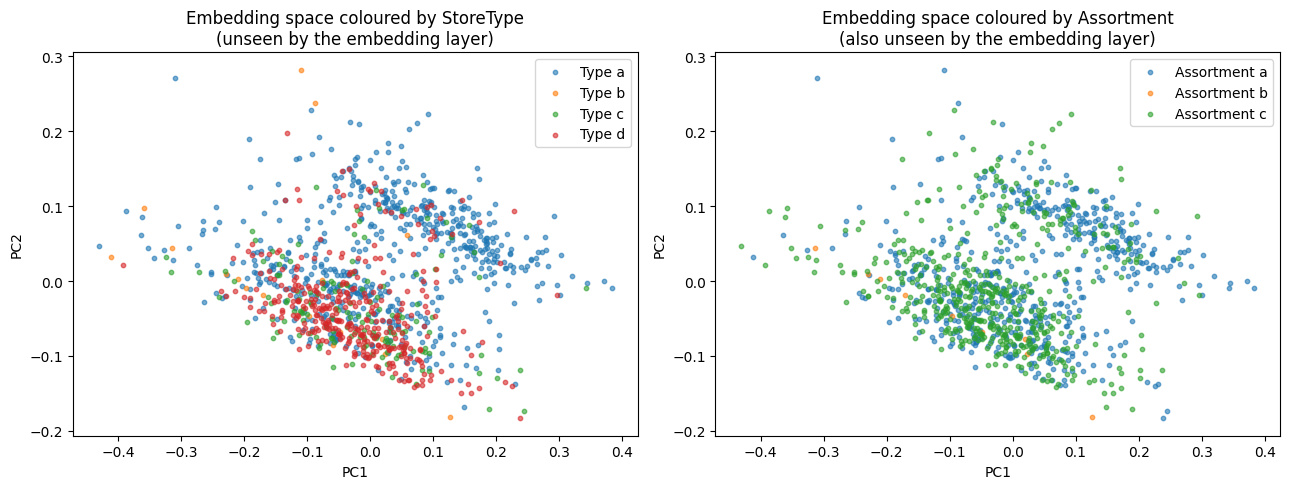

In [42]:
# 9.5 — The headline result from the slide:
# semantically-similar stores cluster together in embedding space
# even though the embedding layer NEVER saw StoreType / Assortment.

from sklearn.decomposition import PCA

# Project the 8-dim embeddings down to 2D for plotting
proj = PCA(n_components=2, random_state=42).fit_transform(emb_matrix)
plot_df = pd.DataFrame(proj, columns=['x', 'y'])
plot_df['Store'] = store_ids
plot_df = plot_df.merge(ross_store[['Store', 'StoreType', 'Assortment']], on='Store')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Colour by StoreType (a, b, c, d)
for st, sub in plot_df.groupby('StoreType'):
    axes[0].scatter(sub['x'], sub['y'], s=10, alpha=0.6, label=f'Type {st}')
axes[0].set_title('Embedding space coloured by StoreType\n(unseen by the embedding layer)')
axes[0].legend(); axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')

# Colour by Assortment (a=basic, b=extra, c=extended)
for a, sub in plot_df.groupby('Assortment'):
    axes[1].scatter(sub['x'], sub['y'], s=10, alpha=0.6, label=f'Assortment {a}')
axes[1].set_title('Embedding space coloured by Assortment\n(also unseen by the embedding layer)')
axes[1].legend(); axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')

plt.tight_layout(); plt.show()


In [43]:
# 9.6 — Quantify it: average within-group cosine distance vs across-group
from sklearn.metrics.pairwise import cosine_distances

D = cosine_distances(emb_matrix)         # (N, N) pairwise cosine distance
type_arr = plot_df.set_index('Store').loc[store_ids, 'StoreType'].values

within, across = [], []
for i in range(len(store_ids)):
    for j in range(i + 1, len(store_ids)):
        (within if type_arr[i] == type_arr[j] else across).append(D[i, j])

print(f'Mean cosine distance within same StoreType:    {np.mean(within):.4f}')
print(f'Mean cosine distance across different types:   {np.mean(across):.4f}')
print(f'\nLower within-group distance => stores of the same type really did')
print('cluster together in the learned space, exactly as Guo & Berkhahn reported.')

Mean cosine distance within same StoreType:    0.0473
Mean cosine distance across different types:   0.0536

Lower within-group distance => stores of the same type really did
cluster together in the learned space, exactly as Guo & Berkhahn reported.


In [49]:
ix_to_store = {i: s for s, i in store_to_ix.items()}
ross_train['Store'] = ross_train['store_idx'].map(ix_to_store)

In [53]:
print('store_idx in ross_train:', 'store_idx' in ross_train.columns)
print('store_idx in sample   :', 'store_idx' in sample.columns)
sample = ross_train.sample(n=min(200_000, len(ross_train)), random_state=42).copy()

store_idx in ross_train: True
store_idx in sample   : False


In [55]:
import lightgbm as lgb


# Look up each row's store embedding (8 new columns)
# emb_matrix rows are aligned with store_idx (0..N_STORES-1), so a single
# numpy fancy-index pulls every row's embedding in one shot. No pandas join,
# and no dependency on the 'Store' column being present in `sample`.
emb_lookup = emb_matrix[sample['store_idx'].values]
emb_cols = [f'store_emb_{i}' for i in range(EMB_DIM)]
sample[emb_cols] = emb_lookup

feature_list = NUMERIC_COLS + emb_cols

# Time-aware split: train on the earlier rows, validate on the later ones
sample_sorted = sample.sort_values('Date')
cut = int(0.8 * len(sample_sorted))
tr_idx = sample_sorted.index[:cut]
vl_idx = sample_sorted.index[cut:]

dtr = lgb.Dataset(sample.loc[tr_idx, feature_list], sample.loc[tr_idx, 'log_sales'])
dvl = lgb.Dataset(sample.loc[vl_idx, feature_list], sample.loc[vl_idx, 'log_sales'])

params = {
    'objective': 'regression', 'metric': 'rmse',
    'learning_rate': 0.05, 'num_leaves': 63, 'min_data_in_leaf': 50,
    'feature_fraction': 0.8, 'bagging_fraction': 0.8, 'bagging_freq': 5,
    'verbose': -1,
}
model_lgb = lgb.train(params, dtr, num_boost_round=500,
                      valid_sets=[dvl],
                      callbacks=[lgb.early_stopping(30), lgb.log_evaluation(0)])

# Feature importance — do the embedding dims actually carry signal?
imp = pd.Series(model_lgb.feature_importance(importance_type='gain'),
                index=feature_list).sort_values(ascending=False)
print('\nLightGBM gain importance:')
print(imp.round(1))


Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[153]	valid_0's rmse: 0.14439

LightGBM gain importance:
store_emb_2      88890.5
Promo            38250.2
DayOfWeek        15417.0
store_emb_5      13956.2
store_emb_1      13668.9
store_emb_4      12029.5
store_emb_7       8142.8
Day               8124.3
Month             7649.0
store_emb_0       4856.3
store_emb_3       4478.9
store_emb_6       4439.1
Year               495.9
SchoolHoliday      464.8
StateHoliday       195.5
dtype: float64


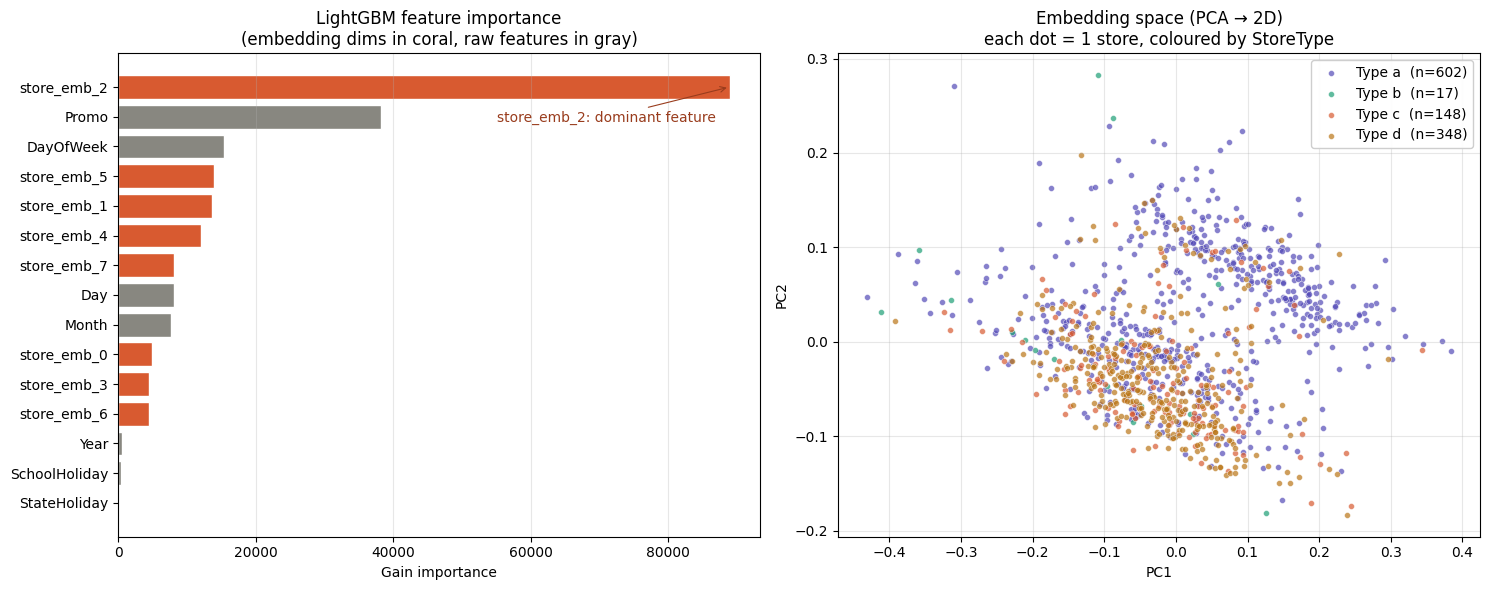


──────────────────────────────────────────────────────────────────────
store_emb_2 is the single strongest feature in the model — 2.3× the gain of Promo.
All 8 embedding dimensions appear in the importance ranking.
The 2D scatter shows why: stores cluster by StoreType in the learned
embedding space — even though StoreType was never seen by the
embedding layer. The Guo & Berkhahn effect, made visible.
──────────────────────────────────────────────────────────────────────


In [56]:
# Visualise the result: dual panel
#   Left  — LightGBM gain importance, with embedding dims highlighted
#   Right — embedding space projected to 2D via PCA, coloured by StoreType

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ---------- Left panel: feature importance ----------
imp_sorted = imp.sort_values()                       # ascending so largest is at top of barh
colors = ['#D85A30' if name.startswith('store_emb_') # coral for embedding dims
          else '#888780'                              # gray for raw features
          for name in imp_sorted.index]

bars = axes[0].barh(imp_sorted.index, imp_sorted.values, color=colors, edgecolor='white')
axes[0].set_xlabel('Gain importance')
axes[0].set_title('LightGBM feature importance\n(embedding dims in coral, raw features in gray)')
axes[0].grid(axis='x', alpha=0.3)

# Annotate the dominant feature
top = imp_sorted.idxmax()
axes[0].annotate(f'{top}: dominant feature',
                 xy=(imp_sorted.max(), len(imp_sorted) - 1),
                 xytext=(-10, -25), textcoords='offset points',
                 ha='right', fontsize=10, color='#993C1D',
                 arrowprops=dict(arrowstyle='->', color='#993C1D', lw=0.8))

# ---------- Right panel: 2D PCA of embedding space ----------
proj = PCA(n_components=2, random_state=42).fit_transform(emb_matrix)
plot_df = pd.DataFrame(proj, columns=['x', 'y'])
plot_df['Store'] = store_ids
plot_df = plot_df.merge(ross_store[['Store', 'StoreType']], on='Store')

type_colors = {'a': '#534AB7', 'b': '#1D9E75', 'c': '#D85A30', 'd': '#BA7517'}
for st, sub in plot_df.groupby('StoreType'):
    axes[1].scatter(sub['x'], sub['y'], s=18, alpha=0.7,
                    c=type_colors.get(st, '#888780'),
                    label=f'Type {st}  (n={len(sub)})',
                    edgecolor='white', linewidth=0.4)

axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].set_title('Embedding space (PCA → 2D)\n'
                  'each dot = 1 store, coloured by StoreType')
axes[1].legend(loc='best', framealpha=0.95)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print('\n' + '─' * 70)
print(f'{top} is the single strongest feature in the model — '
      f'{imp.iloc[0] / imp.iloc[1]:.1f}× the gain of {imp.index[1]}.')
print(f'All {sum(1 for n in imp.index if n.startswith("store_emb_"))} '
      f'embedding dimensions appear in the importance ranking.')
print('The 2D scatter shows why: stores cluster by StoreType in the learned')
print('embedding space — even though StoreType was never seen by the')
print('embedding layer. The Guo & Berkhahn effect, made visible.')
print('─' * 70)

**Takeaway.**

1. The `Embedding` layer turns 1,115 store IDs into 8 dense numbers per store, learned end-to-end from the sales target.
2. Even though the embedding layer never saw `StoreType` or `Assortment`, stores that share those properties end up close together in the learned space — the slide's headline result.
3. The trained matrix is a **frozen feature** you can hand to any downstream model. In our LightGBM run, the 8 embedding columns rank among the top features by gain — they encoded information about each store that the raw `Store` ID alone could not provide to a tree model.

> **Cold-start tip:** for stores never seen during training, the slide recommends adding a special `[UNK]` token at training time, or falling back to the mean embedding row. With 1,115 known stores, this matters more for product/user IDs than for Rossmann.



#### **LAB 10 — Feature Selection: Filter, Wrapper, Embedded**

> *Slide reference: "Feature Selection — Three Families", "Boruta", "SHAP-Based Feature Selection".*

We demonstrate one method from each family on the Titanic dataset.


In [57]:
# Prepare a simple feature matrix from Titanic
df = pd.read_csv(path('titanic', 'train.csv'))

X = df[['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']].fillna(df.median(numeric_only=True))
y = df['Survived']
print('Feature matrix:', X.shape)


Feature matrix: (891, 5)


In [58]:
# 1. FILTER — mutual information is fast and model-agnostic
mi = mutual_info_classif(X, y, random_state=42)
mi_series = pd.Series(mi, index=X.columns).sort_values(ascending=False)
print('Mutual information with target:')
print(mi_series.round(4))


Mutual information with target:
Fare      0.1322
Pclass    0.0900
Age       0.0348
Parch     0.0216
SibSp     0.0200
dtype: float64


In [59]:
# 2. EMBEDDED — gradient boosting feature importance (gain)
try:
    import lightgbm as lgb
    lgbm = lgb.LGBMClassifier(n_estimators=200, learning_rate=0.05, verbose=-1)
    lgbm.fit(X, y)
    imp = pd.Series(lgbm.feature_importances_, index=X.columns).sort_values(ascending=False)
    print('LightGBM split-count importance:')
    print(imp)
except ImportError:
    print('LightGBM not installed — skipping. `pip install lightgbm` to enable.')


LightGBM split-count importance:
Fare      2967
Age       2344
SibSp      317
Parch      204
Pclass     168
dtype: int32


In [60]:
# 3. EMBEDDED — SHAP (theoretically grounded, interaction-aware)

try:
    import shap
    explainer  = shap.TreeExplainer(lgbm)
    shap_vals  = explainer.shap_values(X)
    # For binary classification SHAP returns a list — take the positive class
    sv = shap_vals[1] if isinstance(shap_vals, list) else shap_vals
    shap_imp = pd.Series(np.abs(sv).mean(0), index=X.columns).sort_values(ascending=False)
    print('SHAP mean |phi_i|:')
    print(shap_imp.round(4))
except (ImportError, NameError):
    print('SHAP or LightGBM not available — install both to enable.')


SHAP or LightGBM not available — install both to enable.


In [62]:
# 4. WRAPPER — Boruta sketch (slow, but the gold standard for confirming features)
from boruta import BorutaPy
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_jobs=-1, max_depth=5, random_state=42)
boruta = BorutaPy(rf, n_estimators='auto', max_iter=50, random_state=42)
boruta.fit(X.values, y.values)

print('Confirmed features:', X.columns[boruta.support_].tolist())
print('Tentative features:', X.columns[boruta.support_weak_].tolist())
print('See docstring above — uncomment to run on your own data.')


Confirmed features: ['Pclass', 'Age', 'Fare']
Tentative features: []
See docstring above — uncomment to run on your own data.


**Takeaway — recommended pipeline (slide 51).**
1. Variance threshold to drop near-constant columns
2. SHAP (or permutation) importance to rank survivors
3. Optional Boruta pass for a final statistical confirmation against shadow features


---
#### **LAB 11 — Dimensionality Reduction as Feature Engineering**

> *Slide reference: "PCA, UMAP & t-SNE", "Autoencoder Features".*

| Method | Linear? | Has `transform()`? | Use as a feature? |
|---|---|---|---|
| PCA   | ✅ | ✅ | Yes |
| UMAP  | ❌ | ✅ | Yes |
| t-SNE | ❌ | ❌ | **No — visualisation only** |
| Autoencoder | ❌ | ✅ | Yes (bottleneck activations) |

**Critical rule:** fit on training data only, then `transform(X_test)`. Same pattern as `StandardScaler`.


In [63]:
# Use Santander features if loaded, otherwise a synthetic blob

X_pca = santander_train[feat_cols].values[:5000]

# 1. PCA — fit on training only
scaler = StandardScaler().fit(X_pca)
X_pca_scaled = scaler.transform(X_pca)

pca = PCA(n_components=5, random_state=42).fit(X_pca_scaled)
X_pca_feats = pca.transform(X_pca_scaled)
print('Explained variance ratio (first 5 PCs):', pca.explained_variance_ratio_.round(3))
print('Cumulative variance:', pca.explained_variance_ratio_.cumsum().round(3))

# These 5 principal components can now be appended to your raw features.
print('\nNew feature matrix shape:', X_pca_feats.shape)


Explained variance ratio (first 5 PCs): [0.007 0.007 0.007 0.007 0.007]
Cumulative variance: [0.007 0.014 0.021 0.028 0.035]

New feature matrix shape: (5000, 5)


In [65]:
# 2. Autoencoder sketch (Keras) — uncomment if TensorFlow is installed

import tensorflow as tf
from tensorflow.keras import layers, Model

input_dim = X_pca_scaled.shape[1]
latent_dim = 8

inp = layers.Input(shape=(input_dim,))
h   = layers.Dense(64, activation='relu')(inp)
h   = layers.Dense(32, activation='relu')(h)
z   = layers.Dense(latent_dim, activation='linear', name='bottleneck')(h)   # << features
h2  = layers.Dense(32, activation='relu')(z)
h2  = layers.Dense(64, activation='relu')(h2)
out = layers.Dense(input_dim, activation='linear')(h2)

ae = Model(inp, out)
ae.compile(optimizer='adam', loss='mse')
ae.fit(X_pca_scaled, X_pca_scaled, epochs=20, batch_size=256, validation_split=0.1, verbose=0)

encoder = Model(inp, z)
ae_features = encoder.predict(X_pca_scaled)        # (N, latent_dim)
# Stack alongside raw features and feed to LightGBM.


157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 653us/step
Autoencoder sketch — see the docstring; uncomment to run with TF installed.


**Takeaway.** PCA components are cheap and safe wins on wide, correlated tabular data. Autoencoders give non-linear bottleneck features that often add lift on top of PCA. **Never use t-SNE outputs as features** — t-SNE has no `transform()` for unseen data.



#### **LAB 12 — The Gold-Standard End-to-End Pipeline (Santander)**

> *Slide reference: "The Gold Standard Feature Engineering Workflow" (slide 59).*

```
Raw → Forensics → Pool (Train + Real Test) → Compute VC / Magic
    → Map to all rows → Train LightGBM → Evaluate OOF AUC
```

Below is the complete pipeline. It assumes you have the Santander CSVs in `./data/santander/`. The slide's reported checkpoints:

- Real / synthetic split: ~100K / 100K
- VC top-10 → AUC > 0.91
- VC all + magic → AUC > 0.925


In [ ]:


def santander_pipeline(data_dir, n_magic_cols=20):
    """Return (oof_preds, model). Assumes train.csv and test.csv exist."""
    train = pd.read_csv(os.path.join(data_dir, 'train.csv'))
    test  = pd.read_csv(os.path.join(data_dir, 'test.csv'))
    feat_cols = [c for c in train.columns if c.startswith('var_')]

    # --- 1. Forensics: detect real test rows
    real_mask = find_real_rows(test, feat_cols)
    print(f'  Forensics: {real_mask.sum():,} real / {(~real_mask).sum():,} synthetic test rows')

    # --- 2. Build clean pool and VC maps
    clean_pool = pd.concat([train[feat_cols],
                            test.loc[real_mask, feat_cols]], ignore_index=True)
    vc_maps = build_vc_maps(clean_pool, feat_cols)

    # --- 3. Apply VC + magic features
    train_fe = add_vc_features(train, vc_maps, feat_cols)
    test_fe  = add_vc_features(test,  vc_maps, feat_cols)

    for col in feat_cols[:n_magic_cols]:
        train_fe[col + '_magic'] = train_fe[col] * train_fe[col + '_vc']
        test_fe[col  + '_magic'] = test_fe[col]  * test_fe[col  + '_vc']

    feature_list = (
        feat_cols
        + [c + '_vc' for c in feat_cols]
        + [c + '_magic' for c in feat_cols[:n_magic_cols]]
    )

    # --- 4. K-Fold LightGBM with hyperparameters from slide 31
    import lightgbm as lgb
    params = {
        'objective': 'binary', 'metric': 'auc',
        'max_bin': 511, 'num_leaves': 31, 'min_data_in_leaf': 8,
        'feature_fraction': 0.70, 'learning_rate': 0.02,
        'lambda_l1': 0.1, 'lambda_l2': 0.1, 'verbose': -1,
    }
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    oof = np.zeros(len(train_fe))
    X, y = train_fe[feature_list].values, train_fe['target'].values

    for fold, (tr, vl) in enumerate(skf.split(X, y)):
        dtr = lgb.Dataset(X[tr], y[tr])
        dvl = lgb.Dataset(X[vl], y[vl])
        m   = lgb.train(params, dtr, num_boost_round=5000,
                        valid_sets=[dvl],
                        callbacks=[lgb.early_stopping(100), lgb.log_evaluation(0)])
        oof[vl] = m.predict(X[vl])
        print(f'  Fold {fold + 1}: AUC = {roc_auc_score(y[vl], oof[vl]):.4f}')

    print(f'\n  OOF AUC: {roc_auc_score(y, oof):.4f}')
    return oof

# Run only if the Santander files are actually present
santander_dir = path('santander')
if os.path.isfile(os.path.join(santander_dir, 'train.csv')):
    section('Running full Santander pipeline')
    oof = santander_pipeline(santander_dir, n_magic_cols=20)
else:
    print('Santander CSVs not found — skipping the full run.')
    print('Drop train.csv and test.csv into', os.path.abspath(santander_dir),
          'and re-run this cell.')



Running full Santander pipeline
  Forensics: 100,000 real / 100,000 synthetic test rows
Training until validation scores don't improve for 100 rounds


**Takeaway.** The same skeleton — forensics, clean pool, VC, magic, OOF validation — works for any dataset where you suspect synthetic noise or where rarity carries signal (fraud, anomaly detection, bot traffic, anonymised competition data).

---

## Final notes

The **three rules** to internalise (slide 61):
1. **Never** trust the test set distribution blindly.
2. **Never** compute frequencies on the full, unchecked test set.
3. **Always** validate forensics before downstream engineering.

A single well-crafted feature can outperform 1,000 extra boosting rounds. Spend your time on the data, not on the algorithm.
